UN General Debate Transcripts Dataset from *Understanding State Preferences With Text As Data: Introducing the UN General Debate Corpus*

https://journals.sagepub.com/doi/epub/10.1177/2053168017712821

In this notebook, we generate temporal topic models of the UNGDC with various clustering and Mapper parameters.

Main packages: [temporal mapper](https://github.com/TutteInstitute/temporal-mapper) + [toponymy](https://github.com/TutteInstitute/toponymy).

The next cell contains all relevant parameters to be modified.


In [4]:
"""
Parameters
"""
# Set this to agree with `UNGDC-DataPrep.ipynb`
data_path = "./output_data/UN-2026-03-16"

slice_numbers = [6,10,14]

## Mapper settings
import temporalmapper as tm
mapper_params = {
    "n_neighbors": 500,
    "slice_method": "data",
    "overlap":0.8,
    "kernel":tm.kernels.gaussian,
}
### THE CLUSTERER PARAMS DOMINATE RUNTIME -- MORE CLUSTERS IS EXPONENTIALLY SLOWER ###
clusterer_params = {
    'min_clusters':4,
    'max_layers':3,
    'base_min_cluster_size':50,
    'verbose':False
}

## Toponymy settings
compute_names = False

# Options: 'all-MiniLM-L6-v2' (fast, 384 dim), 'all-mpnet-base-v2' (better quality, 768 dim)
model_name = 'all-MiniLM-L6-v2'

toponymy_object_description = "excerpts from a speech"
toponymy_corpus_description = "United Nations General Debate Transcripts"

toponymy_exemplar_method = "central"
toponymy_keyphrase_method = "information_weighted"
toponymy_subtopic_method = "facility_location"

configuration_dict = {
    'slice_numbers':slice_numbers,
    'mapper_params':mapper_params,
    'model_name':model_name,
    'toponymy_object_description':toponymy_object_description,
    'toponymy_corpus_description':toponymy_corpus_description,
    'toponymy_exemplar_method':toponymy_exemplar_method,
    'toponymy_keyphrase_method':toponymy_keyphrase_method,
    'toponymy_subtopic_method':toponymy_subtopic_method,
    'clusterer_params':clusterer_params,
}

import json
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo
def print_ts(txt):
    now = datetime.now(ZoneInfo('US/Eastern'))
    formatted_datetime = now.strftime("%Y-%m-%d %H:%M:%S")
    print(formatted_datetime+": "+txt)

try:
    Path(data_path).mkdir(parents=True, exist_ok=True)
    # can't JSON serialize the kernel func so gotta do its name instead:
    kernel = mapper_params['kernel']
    configuration_dict['mapper_params']['kernel']=mapper_params['kernel'].__name__
    with open(data_path+'/configuration.json', 'w') as f:
        json.dump(configuration_dict, f, indent=4)
    configuration_dict['mapper_params']['kernel'] = kernel
    print_ts(f"Created experimental folder {data_path}, and saved configuation file.")
except Exception as e:
    print('Error:', e)

import pandas as pd
import numpy as np
from tqdm import tqdm
from pathlib import Path
from tqdm.auto import tqdm
import pickle
# Register tqdm with pandas
tqdm.pandas()

# Import the pre-processed dataset (see: UNGDC-DataPrep.ipynb)
df = pd.read_parquet(
    "https://huggingface.co/datasets/kalebr/un-general-debate-corpus-chunked/resolve/main/ungdc-all-chunked.parquet"
)


embedding_vectors = df['embedding'].to_numpy()
reduced_vectors = df['reduced'].to_numpy()
text = df['chunk_text'].to_numpy()
time = df['year'].to_numpy()

# Sort all arrays by time
sorted_idx = np.argsort(time)
time = time[sorted_idx]
text = text[sorted_idx]
reduced_vectors = np.vstack(reduced_vectors[sorted_idx])
embedding_vectors = np.vstack(embedding_vectors[sorted_idx])
reduced_vectors_with_time = np.hstack([reduced_vectors, time.reshape(-1,1)])

2026-03-16 21:21:38: Created experimental folder ./output_data/UN-2026-03-16, and saved configuation file.


In [ ]:

## Toponymy Setup
from toponymy import Toponymy, ToponymyClusterer
from toponymy.cluster_layer import ClusterLayerText  
from toponymy.llm_wrappers import AzureAINamer, AnthropicNamer

api_key_file = "claude-api.txt"
with open(api_key_file, 'r') as file:
    api_key = file.read().strip()
Initialize Cohere wrapper  
llm=AzureAINamer(
    api_key, 
    endpoint=llm_endpoint,
    model="Cohere-command-r-08-2024",
)
  
# Initialize Anthropic wrapper 
llm = AnthropicNamer(
    api_key=api_key,
    model="claude-3-haiku-20240307",  # Fast and cost-effective
    llm_specific_instructions="Generate coherent, descriptive names"
)

# Test connection  
print(llm.test_llm_connectivity())

from sentence_transformers import SentenceTransformer
import torch
# Check if GPU is available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Load the embedding model
model = SentenceTransformer(model_name, device=device)
print(f"Loaded model: {model_name}")

clusterer = ToponymyClusterer(**clusterer_params)

toponymy_params = {
    'llm_wrapper':llm,
    'text_embedding_model':model,
    'clusterer':clusterer,
    'object_description':"excerpts from a speech",
    'corpus_description':"United Nations General Debate Transcripts",
    'exemplar_delimiters':["<EXAMPLE_TRANSCRIPT>\n","\n</EXAMPLE_TRANSCRIPT>\n\n"],
}
toponymy_fit_params = {
    'exemplar_method':toponymy_exemplar_method,
    'keyphrase_method':toponymy_keyphrase_method,
    'subtopic_method':toponymy_subtopic_method,
}

# from pathlib import Path
# if Path("topic_model.pkl").is_file():
#     print("Loading topic model.")
#     with open ('topic_model.pkl', 'rb') as f:
#         topic_model = pickle.load(f)
# else:
#     print("Computing topic model.")
#     topic_model = Toponymy(**toponymy_params)
#     topic_model.fit(text, embedding_vectors, reduced_vectors, **toponymy_fit_params)

Using device: cpu


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded model: all-MiniLM-L6-v2


In [7]:
"""
This is an ad-hoc "Layered Mapper" class to run Mapper at each layer of a Toponymy cluster hierarchy.
"""

from toponymy.clustering import Clusterer, build_cluster_tree, centroids_from_labels
from temporalmapper import TemporalMapper
from toponymy._utils import handle_verbose_params
from copy import deepcopy 
import networkx as nx
import numpy as np
from scipy.sparse import issparse
from sklearn.utils.validation import check_is_fitted, check_array
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

class LayeredMapper():
    def __init__(
        self,
        base_clusterer: Clusterer,
        mapper_params: dict | None = None,
        toponymy_params: dict | None = None,
        verbose: bool = None,
        show_progress_bar: bool = None,
    ):
        self.base_clusterer = base_clusterer
        if mapper_params is None:
            mapper_params = {}
        if toponymy_params is None:
            toponymy_params = {}
        self.mapper_params = mapper_params
        self.toponymy_params = toponymy_params
        
        super().__init__()
        _, self.verbose = handle_verbose_params(
            verbose=verbose, show_progress_bar=show_progress_bar, default_verbose=False
        )

    def fit(
        self,
        text,
        clusterable_vectors: np.ndarray,
        embedding_vectors: np.ndarray,
        projection_index: int = -1,
        layer_class = ClusterLayerText,
        verbose: bool = None,
        show_progress_bar: bool = None,
        **layer_kwargs,
    ) -> Clusterer:
        _, verbose_output = handle_verbose_params(
            verbose=verbose if verbose is not None else self.verbose,
            show_progress_bar=show_progress_bar,
            default_verbose=False,
        )
        base_mapper = TemporalMapper(
            clusterer = None,
            **self.mapper_params,
        )
        lens = clusterable_vectors[:, projection_index]
        data = np.delete(
            clusterable_vectors,
            projection_index,
            axis=1
        )
        if issparse(clusterable_vectors):
            base_mapper._mapper.scaler_ = StandardScaler(copy=False, with_mean=False)
        else:
            base_mapper._mapper.scaler_ = StandardScaler(copy=False)
        base_mapper._mapper._compute_midpoints(lens)
        base_mapper._mapper._compute_density(data, lens)
        base_mapper._mapper._compute_weights(data, lens)
        n_layers = 0
        topic_trees = []
        topic_models = []
        mappers = []
        slicewise_layers = []
        n_slices = len(base_mapper._mapper.slices_)
        for i, slice_ in enumerate(base_mapper._mapper.slices_):
            cvectors = data[slice_]
            evectors = embedding_vectors[slice_]    
            cluster_layers, cluster_tree  = self.base_clusterer.fit_predict(
                clusterable_vectors = cvectors,
                embedding_vectors = evectors,
                layer_class=layer_class,
                verbose=verbose,
                show_progress_bar=show_progress_bar,
                **layer_kwargs,
            )
            print(f"Slice {i} has {len(cluster_layers)} layers")
            self.toponymy_params['clusterer']=self.base_clusterer 
            topic_model =  Toponymy(**self.toponymy_params)
            topic_model.fit(
                text[slice_],
                evectors,
                cvectors,
            )
            topic_models.append(topic_model)
            if len(cluster_layers)>n_layers:
                n_layers = len(cluster_layers)
            topic_trees.append(cluster_tree)
            slicewise_layers.append(cluster_layers)

        layer_clusters = []
        for l in range(n_layers):
            if l>=len(cluster_layers):
                break
            mapper = deepcopy(base_mapper)
            labels = np.full((n_slices, data.shape[0]), -2, dtype=int)
            for i, slice_ in enumerate(base_mapper._mapper.slices_):
                labels[i,slice_] = slicewise_layers[i][l].cluster_labels
                
            mapper._mapper.labels_ = np.array(labels)
            mapper._mapper._add_vertices()
            mapper._mapper._build_adjacency_matrix(lens)
            mapper._mapper._add_edges()
            mapper._mapper.is_fitted_ = True
            mapper.data = data
            mapper.time = lens
            mapper.n_samples = data.shape[0]
            mapper.n_components = data.shape[1]
            mapper.populate_node_attrs()
            t_attrs = nx.get_node_attributes(mapper.G, "slice_no")
            mapper.populate_edge_attrs()
            mapper.is_fitted_ = True
            mapper.assign_topics()
            # Run the clustering logic from TemporalMapper.cluster
            dist = cdist(
                mapper._mapper.midpoints_.reshape(-1,1),
                time.reshape(-1,1)
            )
            pt_max_cluster = np.argmin(
                dist,
                axis=0
            )
            topics = nx.get_node_attributes(mapper.G, 'topic')
            clusters = []
            clrs = []
            for pt,t in enumerate(pt_max_cluster):
                c = mapper.clusters[t,pt]
                clrs.append(c)
                if c != -2:
                    clusters.append(f'{t}:{c}')
                elif c == -2:
                    clusters.append(f'{t}:{-1}')

            layer_clusters.append(clusters)
            mappers.append(mapper)
        self.mappers = mappers
        self.topic_models = topic_models
            

In [8]:

dp = Path(data_path+"/pickled")
dp.mkdir(parents=True, exist_ok=True)
print("Starting computation")
for n_slices in slice_numbers:
    for density_based in {True, False}:
        filename = f"layeredmapper_{n_slices}_db{density_based}.pkl"
        p = Path(data_path+"/pickled/"+filename)
        if p.is_file() and (p.stat().st_size > 1024):
            # If the file is <1024 bytes then I assume it was some save error
            print(f"Skipping N={n_slices}, db={density_based}")
            continue
        mapper_params['n_slices'] = n_slices
        mapper_params['density_based'] = density_based
        clusterer_params['base_min_cluster_size'] = int(150/np.sqrt(n_slices))
        print(f"Computing for N={n_slices}, db={density_based}")
        base_clusterer = ToponymyClusterer(**clusterer_params)
        LM = LayeredMapper(
            base_clusterer,
            mapper_params,
            toponymy_params=toponymy_params
        )
        LM.fit(text, reduced_vectors_with_time, embedding_vectors)
        try:
            fp = data_path+"/pickled/"+filename
            with open(fp, 'wb') as f:
                pickle.dump(LM, f)
            print(f"Saved result to {fp}.")
        except Exception as e:
            print(f"!!=== Saving result failed: {e} ===!!")
        

Starting computation
Computing for N=6, db=False
Slice 0 has 3 layers


Batches:   0%|          | 0/1563 [00:00<?, ?it/s]

Building topic names by layer:   0%|          | 0/3 [00:00<?, ?layer/s]

Slice 1 has 3 layers


Batches:   0%|          | 0/1563 [00:00<?, ?it/s]

Building topic names by layer:   0%|          | 0/3 [00:00<?, ?layer/s]

KeyboardInterrupt: 

## Plotting

In [13]:
from temporalmapper.plotting import squarify_text
import matplotlib.pyplot as plt
def make_cluster_labels(LM):
    cluster_labels = {
        l:{} for l in range(len(LM.mappers))
    }
    
    for layer, mapper in enumerate(LM.mappers):
        for node in mapper.G.nodes():
            if (mapper.G.in_degree(node) == 1) and (mapper.G.out_degree(node)==1):
                 cluster_labels[layer][node] = ""
            else:
                time, cluster = node.split(":")
                time = int(time)
                cluster = int(cluster)
                cluster_labels[layer][node] = squarify_text(LM.topic_models[time].topic_names_[layer][cluster])
    return cluster_labels

def temporal_plot(LM, layer, vertices=None):
    fig, ax = plt.subplots(1,1, figsize=(16,10))
    if vertices is None:
        vertices = LM.mappers[layer].G.nodes()
    
    fontsize = {2:8,1:6,0:5}
    cluster_labels = make_cluster_labels(LM)
    if layer == 0:
        layout_optimization = 'ordered'
    else:
        layout_optimization = 'ordered'
    LM.mappers[layer].temporal_plot(
        ax=ax,
        cluster_labels = cluster_labels[layer],
        layout_optimization = layout_optimization,
        cluster_label_kwargs = dict(fontsize=fontsize[layer]),
        edge_weight_bounds = (1,5),
        node_size_bounds = (5,50),
        node_scaling = 5,
        vertices = vertices,
    )
    label_times = LM.mappers[layer].checkpoints
    label_text = [int(label) for label in label_times]
    ax.set_xticks(label_times, labels=label_text)
    ax.tick_params(axis='x', labelrotation=90)
    ax.tick_params(bottom=True, labelbottom=True)
    N = LM.mapper_params['N_checkpoints']
    g = LM.mapper_params['overlap']
    k = LM.mapper_params['neighbours']
    title_str = f"UNGDC Mapper Temporal Embedding\n Parameters: N={N}, g={g}, k={k}, Layer={layer} "
    if LM.mapper_params['density_based']:
        title_str += "(density based)"
    else:
        title_str += "(standard mapper)"
    ax.set_title(title_str,  fontsize=18)
    plt.tight_layout()
    return fig

In [ ]:
image_path = Path(data_path+"/images")
image_path.mkdir(parents=True, exist_ok=True)

directory_path = Path(data_path+"/pickled") 
pkl_files = list(directory_path.glob("*.pkl"))

for file_path in pkl_files:
    print('plotting from', file_path)
    with open(file_path, 'rb') as f:
        LM = pickle.load(f)
    for layer in range(len(LM.mappers)):
        fig = temporal_plot(LM, layer)
        N = LM.mapper_params['N_checkpoints']
        R = LM.mapper_params['density_based']
        fig.savefig(str(image_path) + "/" + f'tp_N{N}_db{R}_layer{layer}.png')
        fig.show()
        
    


plotting from output_data/UN-2026-03-02-Chronoscope/pickled/layeredmapper_10_dbTrue.pkl


In [9]:
def connected_component(LM, vertex):
    """ Returns nodes in the connected component of `vertex`"""
    layer, time, cluster = vertex.split(":")
    layer = int(layer)
    mapper = LM.mappers[layer]
    subgraph = mapper.vertex_subgraph(time+":"+cluster)
    return subgraph

def down_one_level(LM, vertex):
    """ Returns the nodes connected below 'vertex' in the hierarchy """
    layer, time, cluster = vertex.split(":")
    layer = int(layer)
    time = int(time)
    cluster = int(cluster)
    toponymy = LM.topic_models[time]
    subgraphs = {l:[] for l in range(layer+1)}
    for subvertex in toponymy.cluster_tree_[(layer, cluster)]:
        sublayer, subcluster = subvertex
        for vert in connected_component(LM, f"{sublayer}:{time}:{subcluster}"):
            subgraphs[int(sublayer)].append(vert) 
    subgraphs = {l:np.unique(subgraphs[l]) for l in subgraphs.keys()}
    return subgraphs

In [6]:
for file_path in pkl_files:
    print(file_path)

NameError: name 'pkl_files' is not defined

Mapper graph under Balkans Conflict and Peace


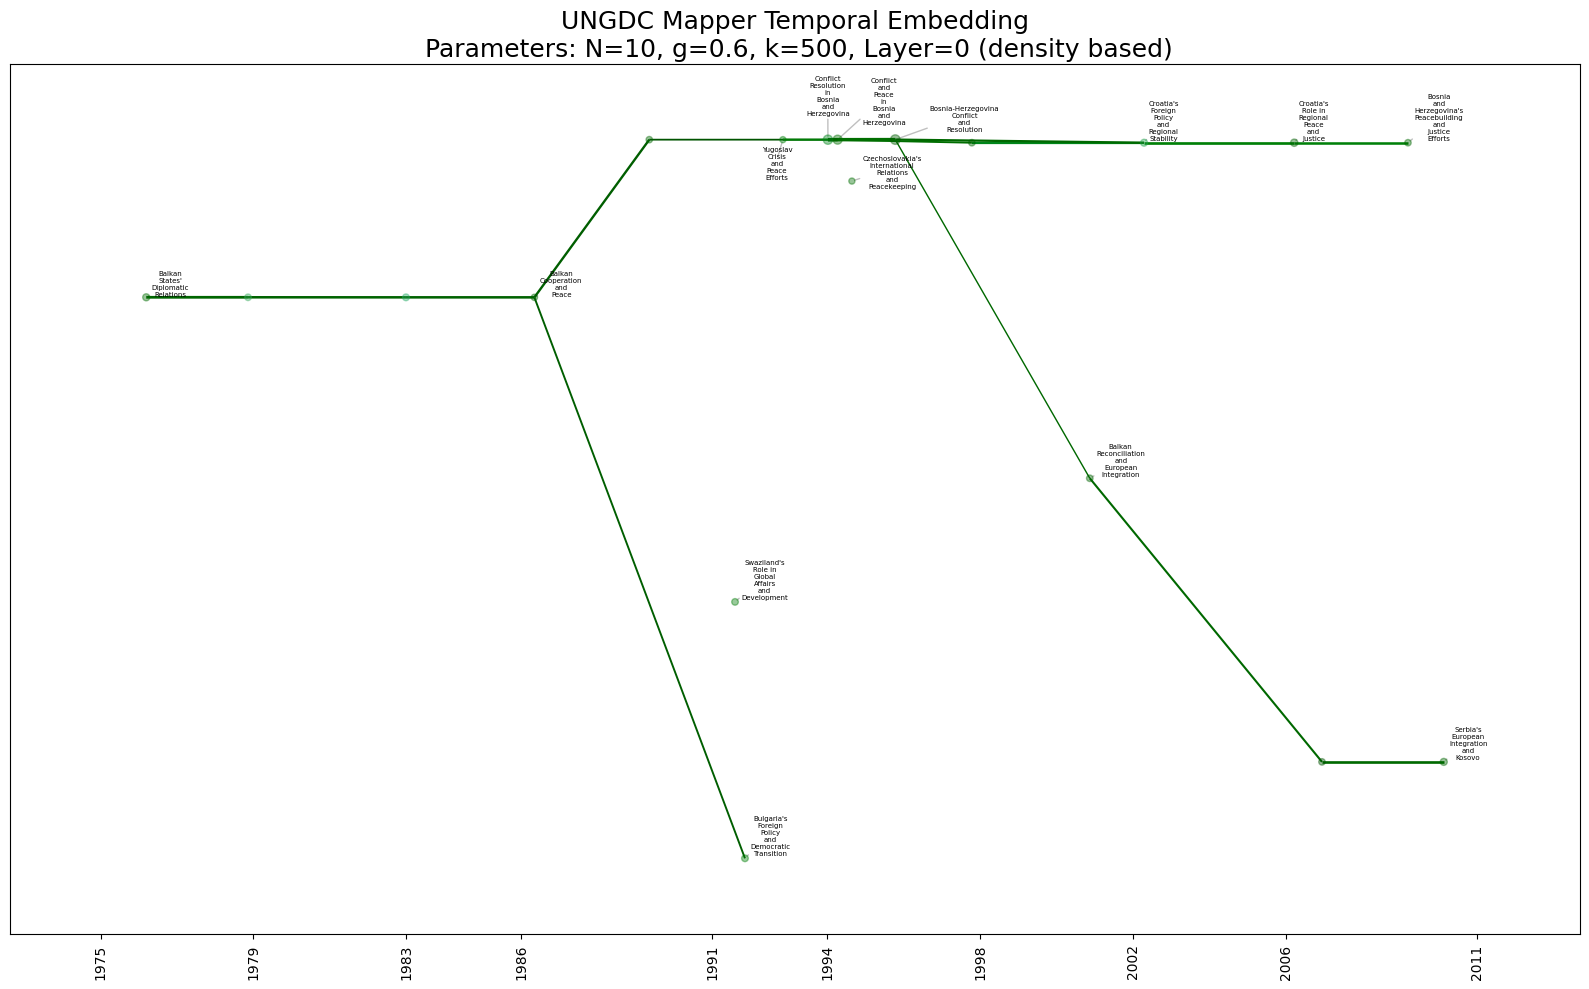

In [12]:
with open('output_data/UN-2026-03-02-Chronoscope/pickled/layeredmapper_10_dbTrue.pkl', 'rb') as f:
        LM = pickle.load(f)
image_path = Path(data_path+"/images")
layer = 0
t=4
l=1
c=6
name = LM.topic_models[t].topic_names_[l][c]
print("Mapper graph under", name)
subgraphs = down_one_level(LM, f"{l}:{t}:{c}")

fig = temporal_plot(LM, layer, subgraphs[layer])
fig.savefig(str(image_path) + "/" + f'subgraph_{name}.png')
fig.show()